# House Prices — Regression Pipeline

End-to-end regression project: from raw data to a tuned XGBoost model.

**Steps:** missing value analysis → EDA (target distribution, correlations, outliers) → ordinal & one-hot encoding → scaling → model comparison (Linear Regression, Random Forest, XGBoost) → hyperparameter tuning.

**Dataset:** [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head()
df.info()
print(df.describe())
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 1. Missing Values

Unlike Titanic, most missing values here are **structural** — they mean "this feature doesn't exist for this house" (e.g. no pool, no garage), not "data was lost". Grouping columns by missing count reveals this pattern clearly.

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Before filling `PoolQC`, check whether the missing values line up with houses that simply have no pool (`PoolArea == 0`).

In [3]:
print(df['PoolArea'].value_counts())

PoolArea
0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64


Confirmed — missing `PoolQC`/`Fence`/`GarageType` means the feature is absent, not unknown. Filled with `'None'` as a valid category rather than dropped or imputed.

In [4]:

df['PoolQC'] = df['PoolQC'].fillna('None')
df['Fence'] = df['Fence'].fillna('None')
df['GarageType'] = df['GarageType'].fillna('None')


df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [5]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

Last remaining gap: a single missing `Electrical` value — genuinely unknown, filled with the mode.

In [6]:
print(df['Electrical'].isnull().sum())

1


In [7]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [8]:
print(df.isnull().sum().sum())
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

3895
MiscFeature     1406
Alley           1369
FireplaceQu      690
GarageCond        81
GarageQual        81
GarageFinish      81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
dtype: int64


Checkpoint — confirming the remaining missing columns before handling the rest of the "structural absence" group (basement, garage, misc features).

In [9]:
df['MiscFeature'] = df['MiscFeature'].fillna('None')
df['Alley'] = df['Alley'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageQual'] = df['GarageQual'].fillna('None')
df['GarageCond'] = df['GarageCond'].fillna('None')

df['BsmtQual'] = df['BsmtQual'].fillna('None')
df['BsmtCond'] = df['BsmtCond'].fillna('None')
df['BsmtExposure'] = df['BsmtExposure'].fillna('None')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('None')

All missing values resolved.

In [10]:
print(df.isnull().sum().sum())

0


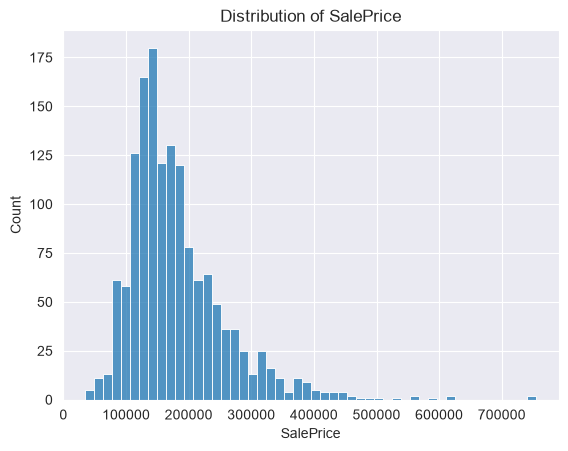

count      1458.000000
mean     180932.919067
std       79495.055285
min       34900.000000
25%      129925.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [42]:
sns.histplot(df['SalePrice'], bins=50)
plt.title('Distribution of SalePrice')
plt.show()

print(df['SalePrice'].describe())

## 2. Target Variable — SalePrice

Checking the distribution of the value we're predicting before anything else.

1.8828757597682129


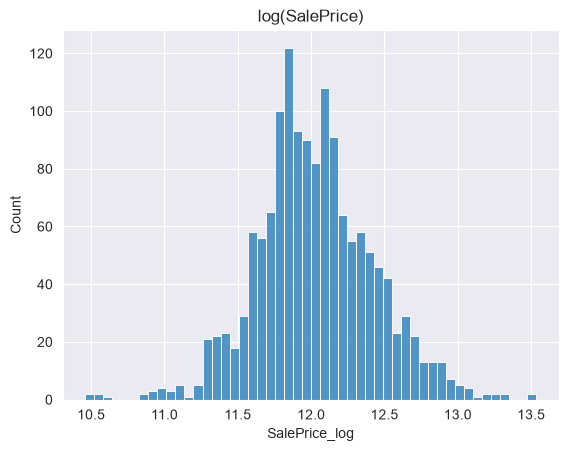

0.12134661989685333


In [12]:
print(df['SalePrice'].skew())
df['SalePrice_log'] = np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice_log'], bins=50)
plt.title('log(SalePrice)')
plt.show()

print(df['SalePrice_log'].skew())

`SalePrice` is heavily right-skewed (a long tail of expensive homes). Applying `log1p` compresses that tail and brings the distribution closer to normal — regression models typically perform better on a symmetric target.

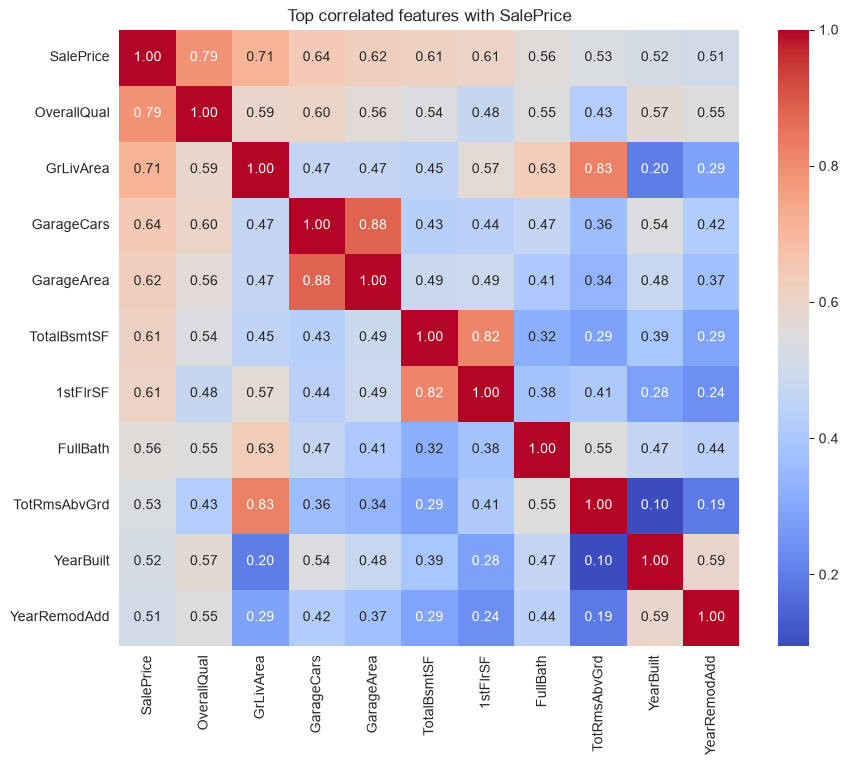

In [18]:
numeric_df = df.select_dtypes(include='number')
correlation_with_target = numeric_df.corr()['SalePrice'].drop(['SalePrice', 'SalePrice_log'])
top_features = correlation_with_target.abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[['SalePrice'] + list(top_features)].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top correlated features with SalePrice')
plt.show()

Checking multicollinearity: `GarageCars`/`GarageArea` and `TotalBsmtSF`/`1stFlrSF` likely measure overlapping information.

In [19]:
print(df[['GarageCars', 'GarageArea']].corr())
print(df[['TotalBsmtSF', '1stFlrSF']].corr())

            GarageCars  GarageArea
GarageCars    1.000000    0.882475
GarageArea    0.882475    1.000000
             TotalBsmtSF  1stFlrSF
TotalBsmtSF      1.00000   0.81953
1stFlrSF         0.81953   1.00000


## 4. Relationship & Outlier Check

Visualizing the top features against price to check linearity and spot outliers.

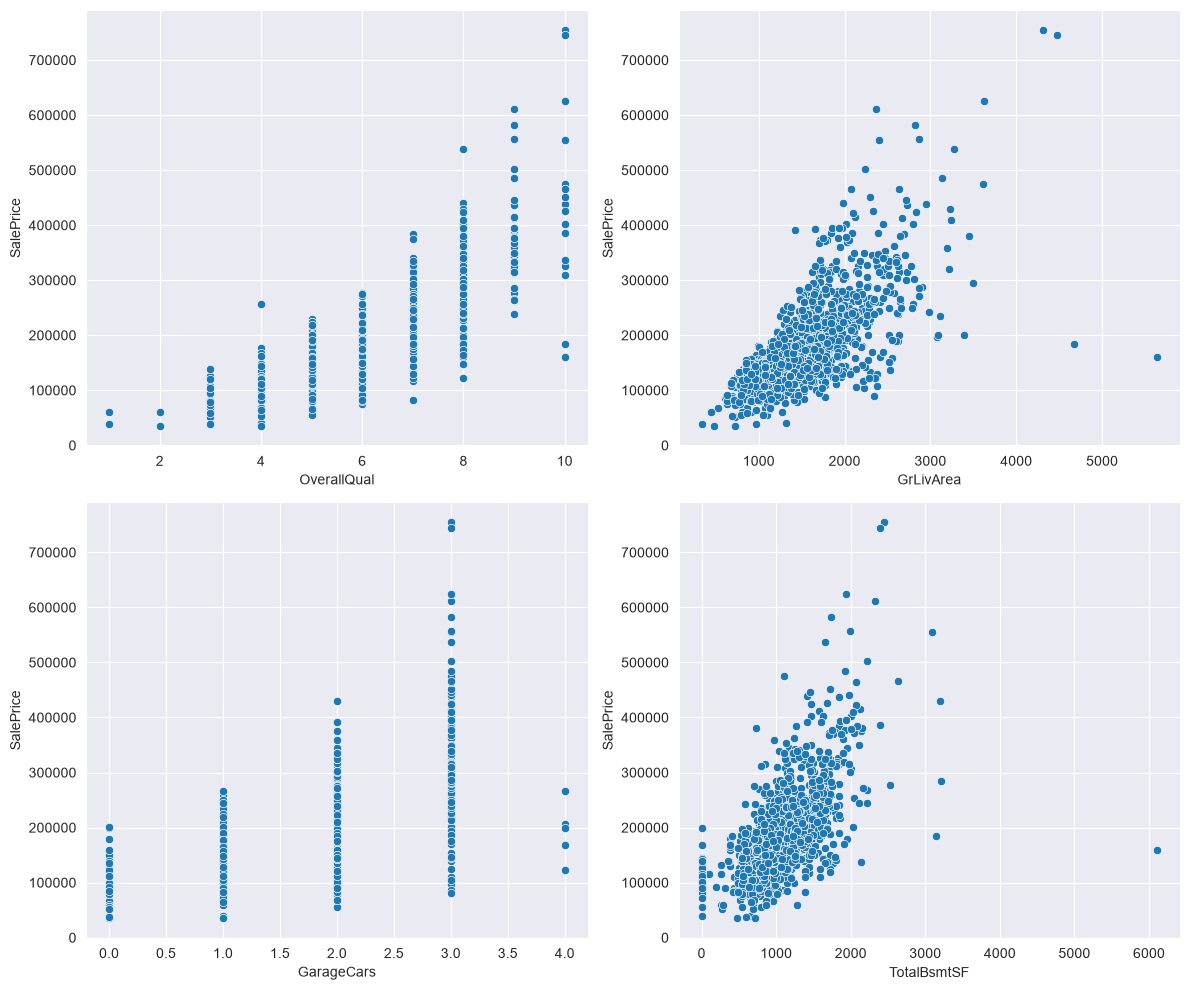

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0,0])
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0,1])
sns.scatterplot(x='GarageCars', y='SalePrice', data=df, ax=axes[1,0])
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, ax=axes[1,1])
plt.tight_layout()
plt.show()

## 5. Categorical Features — Neighborhood

Correlation only works on numeric columns, so categorical impact (like location) has to be checked separately via grouping/boxplots. Neighborhood shows a large price spread — over 3x between the cheapest and most expensive areas.

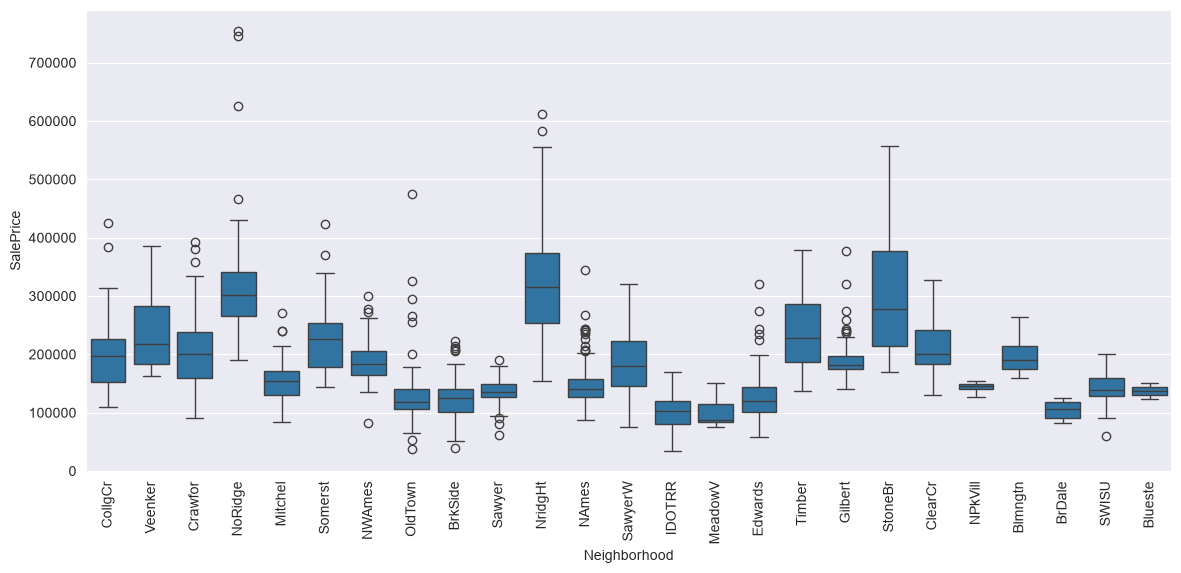

In [23]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.show()

## 6. Outlier Removal

Two homes with very large living area but unusually low price stand out on the scatter plot above.

In [22]:
print(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)])

Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice, SalePrice_log]
Index: []

[0 rows x 82

In [21]:
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]

## 7. Encoding Categorical Features

Two types of categorical features need different treatment:
- **Ordinal** (quality ratings like `ExterQual`, `KitchenQual`) → mapped to an explicit order (`None` < `Po` < `Fa` < `TA` < `Gd` < `Ex`), since alphabetical encoding would misrepresent the scale
- **Nominal** (`Neighborhood`, `MSZoning`, etc., no inherent order) → one-hot encoded

In [24]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'GarageQual', 'GarageCond', 'PoolQC', 'FireplaceQu']

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

Checking what's left after ordinal encoding, before one-hot encoding the rest.

In [25]:
remaining_categorical = df.select_dtypes(include='object').columns
print(remaining_categorical)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
       'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_16652\3169597052.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_categorical = df.select_dtypes(include='object').columns


In [26]:
df = pd.get_dummies(df, columns=remaining_categorical, drop_first=True)

In [27]:
print(df.shape)

(1458, 231)


In [28]:
print(df.select_dtypes(include=['object', 'str']).columns)

Index([], dtype='str')


## 8. Feature Scaling

Standardizing continuous numeric features (area, square footage) so their scale doesn't distort distance- or coefficient-based models. One-hot columns are already 0/1 and don't need scaling.

In [29]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                     'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
                     'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                     '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

## 9. Train/Test Split

`Id` is dropped as a non-predictive identifier. The target is `SalePrice_log`, the transformed version from step 2 — predictions are converted back to dollars later for interpretability.

In [30]:
X = df.drop(['SalePrice', 'SalePrice_log', 'Id'], axis=1)
y = df['SalePrice_log']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 10. Model 1 — Linear Regression

A simple baseline for regression.

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


predictions = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')

MAE: 0.0914
RMSE: 0.1305
R²: 0.8990


In [34]:
predictions_dollars = np.expm1(predictions)
y_test_dollars = np.expm1(y_test)

mae_dollars = mean_absolute_error(y_test_dollars, predictions_dollars)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, predictions_dollars))

print(f'MAE: ${mae_dollars:,.2f}')
print(f'RMSE: ${rmse_dollars:,.2f}')

MAE: $15,572.53
RMSE: $22,019.92


In [ ]:
print(df['SalePrice'].median())
print(df['SalePrice'].mean())

## 11. Model 2 — Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_predictions_dollars = np.expm1(rf_predictions)

rf_mae = mean_absolute_error(y_test_dollars, rf_predictions_dollars)
rf_rmse = np.sqrt(mean_squared_error(y_test_dollars, rf_predictions_dollars))
rf_r2 = r2_score(y_test, rf_predictions)

print(f'Random Forest MAE: ${rf_mae:,.2f}')
print(f'Random Forest RMSE: ${rf_rmse:,.2f}')
print(f'Random Forest R²: {rf_r2:.4f}')

Random Forest MAE: $16,415.68
Random Forest RMSE: $23,842.37
Random Forest R²: 0.8761


## 12. Model 3 — XGBoost

Unlike Random Forest's independent trees, XGBoost builds trees sequentially, each correcting the previous ones' errors.

In [37]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_predictions_dollars = np.expm1(xgb_predictions)

xgb_mae = mean_absolute_error(y_test_dollars, xgb_predictions_dollars)
xgb_rmse = np.sqrt(mean_squared_error(y_test_dollars, xgb_predictions_dollars))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f'XGBoost MAE: ${xgb_mae:,.2f}')
print(f'XGBoost RMSE: ${xgb_rmse:,.2f}')
print(f'XGBoost R²: {xgb_r2:.4f}')



XGBoost MAE: $16,394.11
XGBoost RMSE: $23,629.55
XGBoost R²: 0.8724


## 13. Hyperparameter Tuning

Both Random Forest and XGBoost underperformed the simple Linear Regression baseline out of the box. Tuning XGBoost's key hyperparameters (`n_estimators`, `max_depth`, `learning_rate`) via grid search with 5-fold cross-validation to see if a better-configured version can close the gap.

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}


## 14. Final Model — Tuned XGBoost

In [39]:
best_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
best_xgb.fit(X_train, y_train)

best_xgb_predictions = best_xgb.predict(X_test)
best_xgb_predictions_dollars = np.expm1(best_xgb_predictions)

best_xgb_mae = mean_absolute_error(y_test_dollars, best_xgb_predictions_dollars)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test_dollars, best_xgb_predictions_dollars))
best_xgb_r2 = r2_score(y_test, best_xgb_predictions)

print(f'Tuned XGBoost MAE: ${best_xgb_mae:,.2f}')
print(f'Tuned XGBoost RMSE: ${best_xgb_rmse:,.2f}')
print(f'Tuned XGBoost R²: {best_xgb_r2:.4f}')

Tuned XGBoost MAE: $14,833.90
Tuned XGBoost RMSE: $20,631.81
Tuned XGBoost R²: 0.9085


## Summary

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | $15,572 | $22,020 | 0.899 |
| Random Forest (default) | $16,416 | $23,842 | 0.876 |
| XGBoost (default) | $16,394 | $23,630 | 0.872 |
| **XGBoost (tuned)** | **$14,834** | **$20,632** | **0.909** |

**Key takeaway:** out-of-the-box tree models underperformed a simple linear baseline, but tuned XGBoost ultimately won — a reminder that model complexity only pays off once properly configured.

**Possible next steps:** feature importance analysis, tuning Random Forest, trying ensembling/stacking.